# Langkah 1: import libary dan insiliasi data sintetis


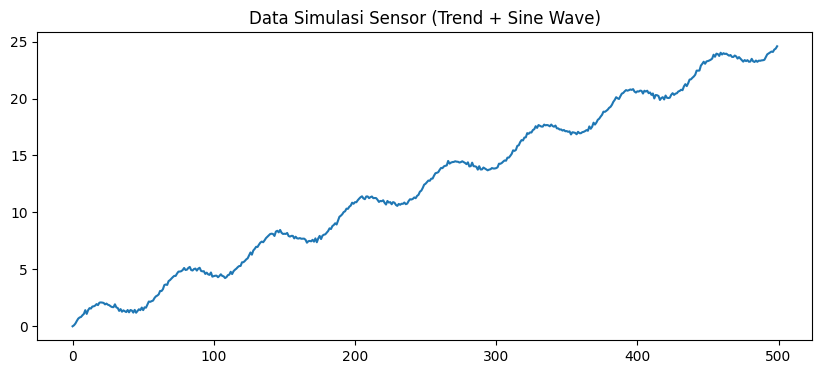

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Membuat data gelombang dengan tren
t = np.arange(0, 500, 1)
data = np.sin(0.1 * t) + 0.05 * t + np.random.normal(0, 0.1, 500)
df = pd.DataFrame(data, columns=['Nilai_Sensor'])

plt.figure(figsize=(10, 4))
plt.plot(df)
plt.title("Data Simulasi Sensor (Trend + Sine Wave)")
plt.show()

# Langkah 2: Normalisai data (scalling)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# Langkah 3: membuat Struktur jendela waktu (windowing)

In [ ]:
def create_windowed_data(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_windowed_data(df_scaled, window_size)

# Reshape ke format 3D [Samples, Timesteps, Features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"Bentuk data X (3D): {X.shape}") # (490, 10, 1)

Bentuk data X (3D): (490, 10, 1)


# Langka 4: Membangun arsitektur LSTM

In [ ]:
model = Sequential([
LSTM(units=50, activation='relu', input_shape=(window_size, 1)),
Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

# Langkah 5: Pelatihan Model (Training)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1944 - val_loss: 0.4966
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0747 - val_loss: 0.0669
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099 - val_loss: 0.0033
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7107e-04 - val_loss: 0.0084
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9621e-04 - val_loss: 0.0047
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6701e-04 - val_loss: 0.0032
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.1109e-04 - val_loss: 0.0045
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7134e-04 - val_loss: 0.0041
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4792e-04 - val_loss: 0.0027
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

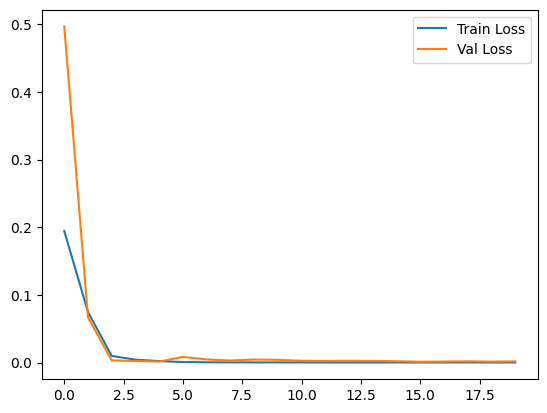

In [ ]:
# Membagi data train (80%) dan test (20%)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Training
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
validation_data=(X_test, y_test), verbose=1)

# Visualisasi Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

# Langkah 6: Prediksi dan Inverse Transform

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


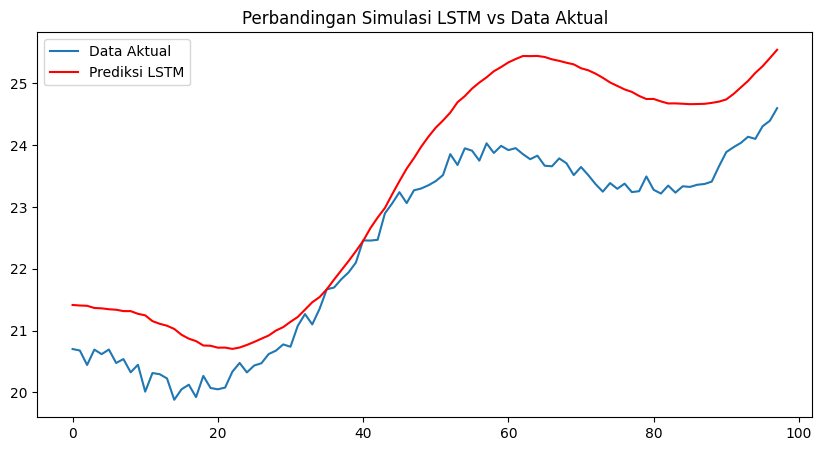

In [ ]:
y_pred_scaled = model.predict(X_test)

# Mengembalikan ke skala asli
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualisasi Hasil Akhir
plt.figure(figsize=(10, 5))
plt.plot(y_actual, label='Data Aktual')
plt.plot(y_pred, label='Prediksi LSTM', color='red')
plt.legend()
plt.title("Perbandingan Simulasi LSTM vs Data Aktual")
plt.show()